In [1]:
# %pip install matplotlib
# %pip install scikit-learn
# %pip install torch
# %pip install "numpy<2"

# INIT

The solution is given by the following article [Eq : 3.4] :

https://arxiv.org/pdf/2406.07507 



In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import torch
import numpy

In [3]:
# 1. Génération de la distribution cible p1
def get_data(n_samples=1000):
    x, _ = make_moons(n_samples=n_samples, noise=0.05)
    return torch.from_numpy(x).float()

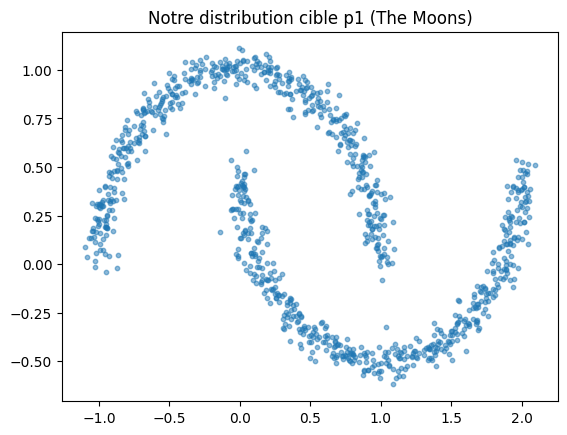

In [4]:
# Visualisation rapide
data = get_data()
plt.scatter(data[:, 0], data[:, 1], s=10, alpha=0.5)
plt.title("Notre distribution cible p1 (The Moons)")
plt.show()

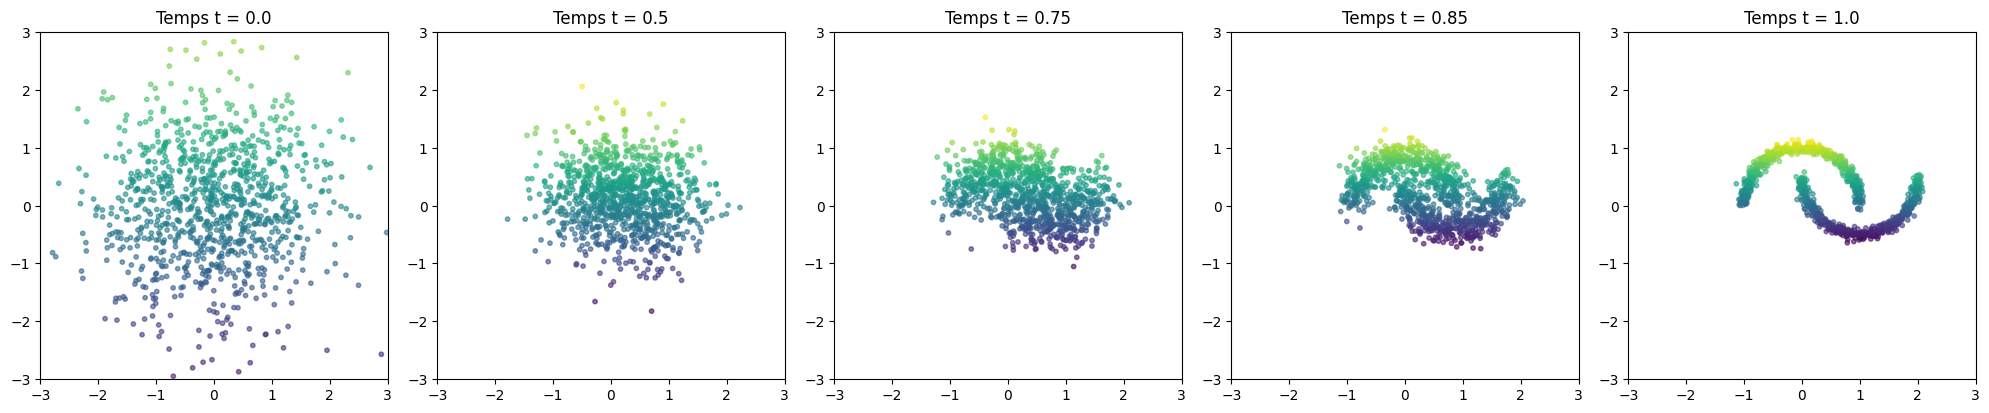

In [6]:
# 1. On prépare nos deux mondes
n_samples = 1000
x1 = torch.from_numpy(make_moons(n_samples=n_samples, noise=0.05)[0]).float() # Data
x0 = torch.randn_like(x1) # Bruit Gaussien

# 2. Fonction d'interpolation linéaire
def interpolate(x0, x1, t):
    return (1 - t) * x0 + t * x1

# 3. Visualisation de la transition
steps = [0.0, 0.5, 0.75, 0.85 ,1.0]
fig, axes = plt.subplots(1, len(steps), figsize=(20, 4))

for i, t in enumerate(steps):
    xt = interpolate(x0, x1, t)
    axes[i].scatter(xt[:, 0], xt[:, 1], s=10, alpha=0.6, c=xt[:, 1], cmap='viridis')
    axes[i].set_title(f"Temps t = {t}")
    axes[i].set_xlim(-3, 3)
    axes[i].set_ylim(-3, 3)
    axes[i].set_aspect('equal')

plt.tight_layout()
plt.show()